The Hamiltonian we are looking at that evolves the quibits is: 

$$H = -\sum_{i=1}^{L} \left( X_i \otimes X_{i+1} + Y_i \otimes Y_{i+1} + J_z Z_i \otimes Z_{i+1} \right)$$

This is the XXZ spin chain model Hamiltonian. It is called as such because the coefficients of $X_i X_{i+1}$ and $Y_i Y_{i+1}$ terms are equal, and the coefficient of $Z_i Z_{i+1}$, called $J_z$, known as the anisotropy parameter, is generally different. 
The operators $X_i$, $Y_i$, and $Z_i$ are respectively the Pauli matrices acting on the spin at lattice site $i$. 
Each term in H couples site $i$ and its nearest neighbor $i+1$, thus each interaction is strictly local. 

Thus, this is describiting a 1D lattice chain of quantum spins with nearest neighbor interactions. This means
lattice site has a spin-$\tfrac{1}{2}$ degree of freedom, ie, each site has a two–dimensional Hilbert space $\mathbb{C}^2$, spanned by the basis states $|0\rangle$ and $|1\rangle$.

The Hilbert space of the full spin chain is therefore the tensor product
$$
\mathcal{H} = (\mathbb{C}^2)^{\otimes L},
$$
which has total dimension $2^L$.

If there are $L$ lattice sites, then we say that there are $L$ local degrees of freedom.

Import cell:

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit.primitives import StatevectorEstimator

Parameter cell:

In [72]:
L =  3
Jz = -3
n_steps = 500 # number of time steps
dt = 0.001

In [73]:
pauli_x = np.array([[0, 1], [1, 0]], dtype=complex)
pauli_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
pauli_z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

def kron_all(operators):    
    """Tensor product of a list of single-site operators"""
    new = operators[0]
    for op in operators[1:]:
        new = np.kron(new, op)
    return new

def AA_operator(L, i, A):
    """
    Inputs: Lattice length L, lattice site i, operator A (in our H, will be a pauli matrix)
    Returns: A (2**L)x(2**L) dense matrix (that is an L-length tensor product of identity matrices, except site i and site i+1 are operator A)
    """ 
    operators = [I] * L # builds an L length array of identiy matrices 
    operators[i] = A # replaces index i of array with chosen operator A 
    operators[i+1] = A # replaces index i+1 with A
    return kron_all(operators)

def dense_XXZ_hamiltonian(L, Jz):
    """Classical dense matrix form of 1D XXZ Hamiltonian
    Inputs: number of lattice sites L, anisotropy parameter Jz
    Outputs: H
    """
    dim = 2**L  # dimension of the hilbert space 
    H = np.zeros((dim, dim), dtype=complex) # initializing empty 2D array H to fill

    for i in range(L - 1):  # building H 
        H += AA_operator(L, i, pauli_x) 
        H += AA_operator(L, i, pauli_y)
        H += Jz * AA_operator(L, i, pauli_z)

    return -H

In [74]:
def sparse_XXZ_hamiltonian(L,Jz):
    """
    Constructs the XXZ Hamiltonian as a SparsePauliOp using Qiskit!

    Inputs: lattice length L, anisotropy coeff Jz 
    Returns: SparsePauliOp Hamiltonian H 
    """
    H_array = []

    for i in range(L-1): 
        H_array.append(("XX", [i, i+1], -1))
        H_array.append(("YY", [i, i+1], -1))
        H_array.append(("ZZ", [i, i+1], -Jz))

    H= SparsePauliOp.from_sparse_list(H_array, num_qubits=L)

    return H

In [75]:
# CHECK BLOCK

H = sparse_XXZ_hamiltonian(L, Jz)
print(H)

H_matrix = H.to_matrix()
print(H_matrix.shape)

SparsePauliOp(['IXX', 'IYY', 'IZZ', 'XXI', 'YYI', 'ZZI'],
              coeffs=[-1.+0.j, -1.+0.j,  3.+0.j, -1.+0.j, -1.+0.j,  3.+0.j])
(8, 8)


In [76]:
def initialise(Jz, L):
    """ 
    Decides the initial state depending on Jz cases (all spin up 00..0 state fixed for jz greater than 1)
    Inputs: anisotropy coeff Jz, lattice length L
    Returns: a statevector
    """

    if Jz > 1: 
        psi0 = Statevector.from_label("0"*L) # all spin up state
        #psi1= Statevector.from_label("1"*L) # all spin down state
        return psi0

    elif Jz < -1:
        
        s = ""
        for i in range(L):
            if (i % 2) == 0: #if i is even 
                s += "1" #add 1 
            else:
                s += "0" #add 0 if i is odd 
        psi0 = Statevector.from_label(s) # alternating state
        return psi0

    else:
        raise ValueError("Jz must be > 1 or < -1")
    

In [77]:
qc = QuantumCircuit(L)
psi0 = initialise(Jz, L)

#print(psi0.probabilities_dict())

def rotate_initialstate(psi0, L, theta=np.pi/2): 
    middle_site = L // 2         
    qc = QuantumCircuit(L)
    qc.ry(theta, middle_site)
    return psi0.evolve(qc)

rotated_psi = rotate_initialstate(psi0, L, theta=np.pi/2)
#print(rotated_psi.probabilities_dict())

Ready to time evolve!

Classical:

In [78]:
Hmat = dense_XXZ_hamiltonian(L, Jz)   

def Ai(L, i, A):
    array = [I]*L
    array[i] = A # measure spin on site i via operator A (which will be a pauli matrix)
    return kron_all(array)

Z_t = np.zeros((n_steps, L)) # Initialise an empty 2D array to store the observables computed where the rows are the time step n and the column is site i of L
X_t = np.zeros((n_steps, L))
Y_t = np.zeros((n_steps, L))

X_ops = [Ai(L, i, pauli_x) for i in range(L)]
Y_ops = [Ai(L, i, pauli_y) for i in range(L)]
Z_ops = [Ai(L, i, pauli_z) for i in range(L)]

psi0 = rotated_psi.data

for n in range(n_steps):                          # Run a loop over timesteps
    Ut = expm(- 1j * Hmat * dt * n)               # Compute the time evolution operator that evolves the system to time dt * n for n timesteps
    psi_t = Ut @ psi0                 # Apply the time evolution operator to the rotated initial state in order to construct |psi(t)>
    
    for i in range(L):
        Z_t[n, i] = (psi_t.conj().T @ Z_ops[i] @ psi_t).real  # Compute the exp value of the Z projection of site i and save to [n,i] of Z_t array
        X_t[n, i] = (psi_t.conj().T @ X_ops[i] @ psi_t).real
        Y_t[n, i] = (psi_t.conj().T @ Y_ops[i] @ psi_t).real
    
    # All observables are Hermitian so exp values are real 

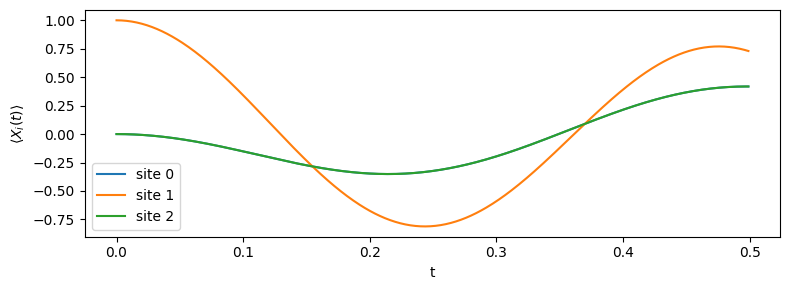

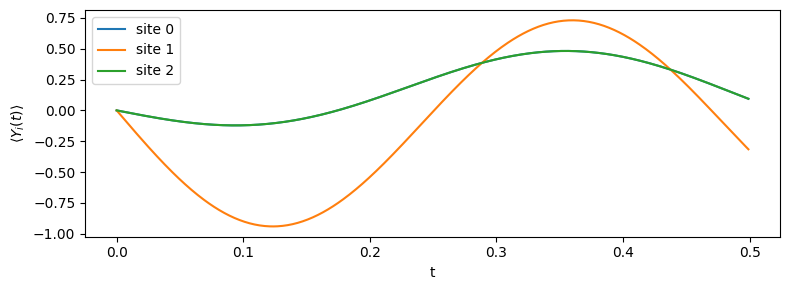

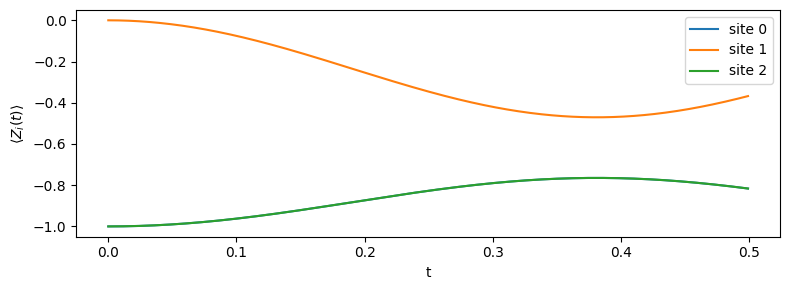

In [79]:
tlist = dt * np.arange(n_steps) 

def plot_observable(data, label):
    plt.figure(figsize=(8,3))
    for i in range(L):
        plt.plot(tlist, data[:, i], label=f"site {i}")
    plt.xlabel("t")
    plt.ylabel(label)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_observable(X_t, r"$\langle X_i(t) \rangle$")
plot_observable(Y_t, r"$\langle Y_i(t) \rangle$")
plot_observable(Z_t, r"$\langle Z_i(t) \rangle$")

Quantum time!

In [85]:
gate = PauliEvolutionGate(dt * H)
st = SuzukiTrotter(order=1, reps=1)

circ = st.synthesize(gate)
#circ.decompose().draw("mpl")
estimator = StatevectorEstimator()

def pauli_string(L, i, P): # Mirrors classical Ai def
    label = ["I"] * L
    label[i] = P
    return SparsePauliOp(["".join(label)], coeffs=[1])

Z_obs_list = [pauli_string(L, i, "Z") for i in range(L)]
X_obs_list = [pauli_string(L, i, "X") for i in range(L)]
Y_obs_list = [pauli_string(L, i, "Y") for i in range(L)]

st = SuzukiTrotter(order=1, reps=1)
circ = st.synthesize(gate)

# Initializing empty matrices to store measured observables
quantum_Z_t = np.zeros((n_steps, L))
quantum_X_t = np.zeros((n_steps, L))
quantum_Y_t = np.zeros((n_steps, L))

# Prepares |psi(0)> with initial vector with rotation
qc = QuantumCircuit(L)
qc.initialize(rotated_psi.data, range(L))

for n in range(n_steps):
    quantum_Z_t[n, :] = np.real(estimator.run(pubs=[(qc, Z_obs_list)]).result()[0].data.evs) # Projection at current time (t = n*dt)
    quantum_X_t[n, :] = np.real(estimator.run(pubs=[(qc, X_obs_list)]).result()[0].data.evs)
    quantum_Y_t[n, :] = np.real(estimator.run(pubs=[(qc, Y_obs_list)]).result()[0].data.evs)

    qc.append(circ, list(range(L))) 

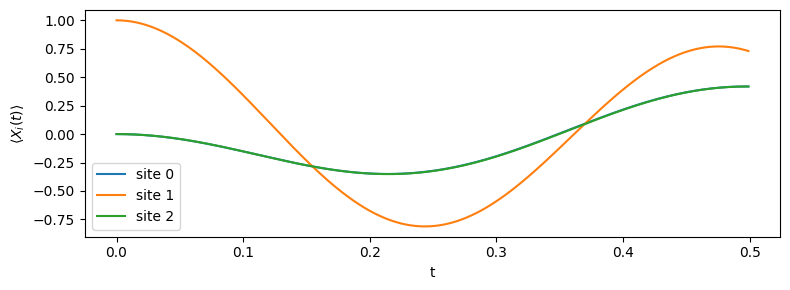

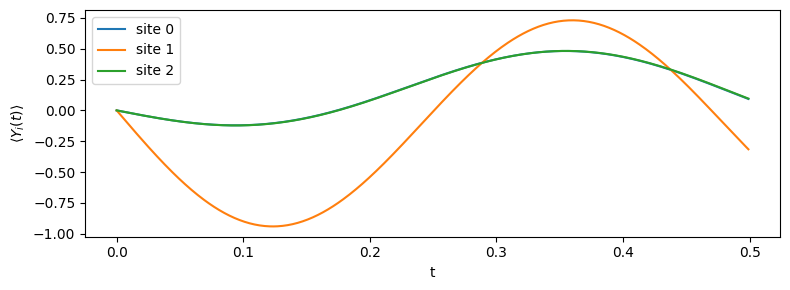

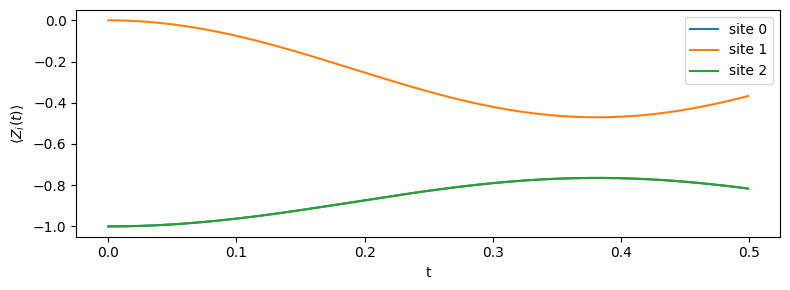

In [84]:
plot_observable(quantum_X_t, r"$\langle X_i(t) \rangle$")
plot_observable(quantum_Y_t, r"$\langle Y_i(t) \rangle$")
plot_observable(quantum_Z_t, r"$\langle Z_i(t) \rangle$")